In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Domain & Period

In [2]:
iyear=1960
fyear=2024
nx=10;ny=10
dom='GRq'
dom_NST = 'GRc'
year_NST = '2000'

# Elevation data

In [3]:
ds_grM= xr.open_dataset(f'/home/santolam/NST.{year_NST}.01.01.00.{dom_NST}.nc')
LONS=ds_grM.LON[ny:-ny,nx:-nx].values
LATS=ds_grM.LAT[ny:-ny,nx:-nx].values
dsSH=ds_grM.SH[ny:-ny,nx:-nx]
latS=LATS.min(); latN=LATS.max()
lonW=LONS.min(); lonE=LONS.max()

elev = dsSH
elev = elev.rename({'x': 'X', 'y': 'Y'})

# Temperature Data (first sigma pressure level)

In [4]:
TTZ = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/TT_monmean_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['TT'][:,0,:,:] # 0 = first pressure level at surface

#Domain & period def
TTZ = TTZ.rename({'TIME': 'time'})
TTZ = TTZ[:,ny:-ny,nx:-nx].sel(time=slice(str(iyear),str(fyear)))

# ICE MASK on TTZ

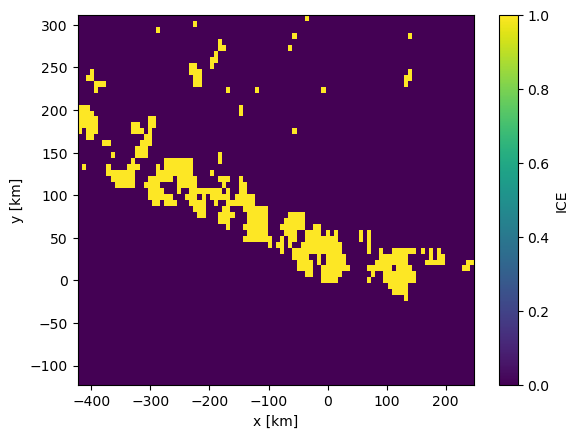

In [5]:
# ICE variable
dsICE=ds_grM.ICE[nx:-nx,ny:-ny]

#ICE mask
ICE_mask = dsICE > 0
ICE_mask = ICE_mask.rename({'x': 'X', 'y': 'Y'})

ICE_mask.plot()

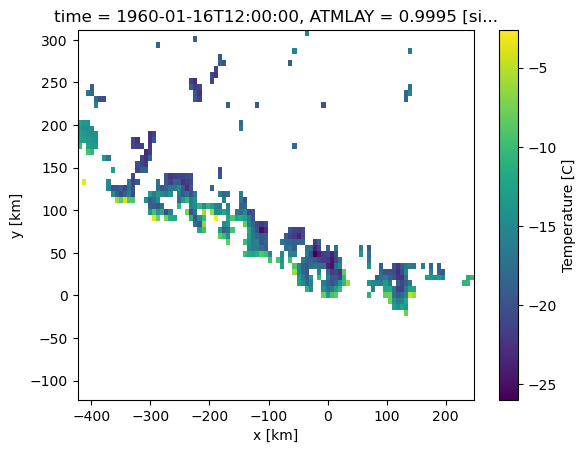

In [6]:
#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
ICE_mask = ICE_mask.assign_coords({
    "X": TTZ.X,
    "Y": TTZ.Y
})

# ICE_mask on TTZ
TTZ = TTZ.where(ICE_mask)
TTZ.isel(time=0).plot()

# Temperature mean per elevation bands (step = 250 m)

In [7]:
# Altitude bands per 250 m
elev_bands = np.arange(3250, 6501, 250)

#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": TTZ.X,
    "Y": TTZ.Y
})

# t2m mean per band of 250 m
TTZ_bands = TTZ.groupby_bins(elev, bins=elev_bands).mean()

# Freezing Level Height (FLH) Calculation

In [8]:
# Center of every elev band (ex : [0,250[ = 125)
zcenters = np.array([interval.mid for interval in TTZ_bands.SH_bins.values])

# Temperature selon les bandes d'altitude
Tz = TTZ_bands.values   # shape (time, elevation_bin)

# Creating a FLH table with shape (time, FLH) full of NaN for FLH
freezing = np.full(Tz.shape[0], np.nan)

# Boucle pour chaque pas de temps dans time
for t in range(Tz.shape[0]):

    profile = Tz[t, :] # Profile de température pour le pas de temps t
    valid = ~np.isnan(profile) # mask pour enlever les NaN 

    z = zcenters[valid] # Altitude où pas de NaN
    Tprof = profile[valid] # Temperature associée où pas de NaN

    # Il faut au mins 2 points pour détecter le changement de signe si non pas continuer et donc NaN
    if len(Tprof) < 2:
        continue

    sign = np.sign(Tprof) # +1 si T > 0 , 0 si T = 0 , -1 si T < 0
    # Indice où T Traverse le zéro 
    cross = np.where(np.diff(sign) != 0)[0] # np.diff(sign) = Différence entre points successifs donc si changement de signe =! 0

    # Si on traverse bien le zéro donc s'il y a bien un FLH    
    if len(cross) > 0:
        # indice où le signe change entre deux niveaux successifs
        i = cross[0]  # première intersection (plus basse)

        z1, z2 = z[i], z[i+1]
        T1, T2 = Tprof[i], Tprof[i+1] # T1 > 0 & T2 < 0
            
        freezing[t] = z1 + (0 - T1) * (z2 - z1) / (T2 - T1) # Interpolation linéaire selon la formule

# Ploting for 2000-2001 to have visualisation

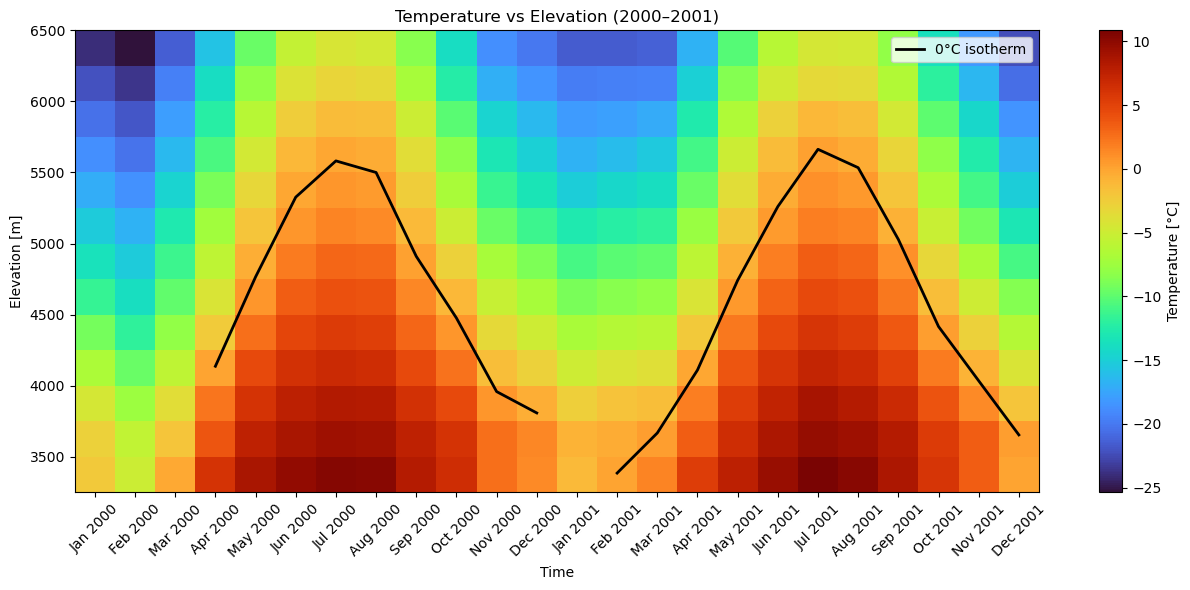

In [9]:
TT = TTZ_bands.sel(time=slice("2000", "2001"))
time = pd.to_datetime(TT.time.values)
time_num = np.arange(len(time))
Tz = TT.values   # shape (time, altitude)
zcenters = np.array([b.mid for b in TT.SH_bins.values])
freezing_plot = np.full(Tz.shape[0], np.nan)

for t in range(Tz.shape[0]):

    profile = Tz[t, :]
    valid = ~np.isnan(profile)

    z = zcenters[valid]
    Tprof = profile[valid]

    if len(Tprof) < 2:
        continue

    sign = np.sign(Tprof)
    cross = np.where(np.diff(sign) != 0)[0]

    if len(cross) > 0:
        i = cross[0]

        z1, z2 = z[i], z[i+1]
        T1, T2 = Tprof[i], Tprof[i+1]

        freezing_plot[t] = z1 + (0 - T1) * (z2 - z1) / (T2 - T1)

plt.figure(figsize=(13,6))
plt.pcolormesh(
    time_num,
    zcenters,
    Tz.T,
    shading="auto",
    cmap="turbo"
)
months = pd.to_datetime(time).to_period("M")
unique_idx = np.unique(months, return_index=True)[1]
plt.xticks(
    unique_idx,
    pd.to_datetime(time[unique_idx]).strftime("%b %Y"),
    rotation=45
)
plt.plot(
    time_num,
    freezing_plot,
    color="k",
    lw=2,
    label="0°C isotherm"
)

plt.ylabel("Elevation [m]")
plt.xlabel("Time")
plt.colorbar(label="Temperature [°C]")
plt.title("Temperature vs Elevation (2000–2001)")
plt.legend()

plt.tight_layout()
plt.show()

# Saving FLH as csv

In [10]:
df = pd.DataFrame({
    "time": pd.to_datetime(TTZ.time.values),
    "FLH": freezing
})

df.to_csv(f"/bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_ICE_monthly_timeseries_MAR_{iyear}-{fyear}_{dom}.csv", index=False)
print(f"Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_ICE_monthly_timeseries_MAR_{iyear}-{fyear}_{dom}.csv")

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_ICE_monthly_timeseries_MAR_1960-2024_GRq.csv


In [11]:
df = pd.read_csv(f"/bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_ICE_monthly_timeseries_MAR_{iyear}-{fyear}_{dom}.csv", parse_dates=["time"])

(np.float64(10957.0), np.float64(11687.0))

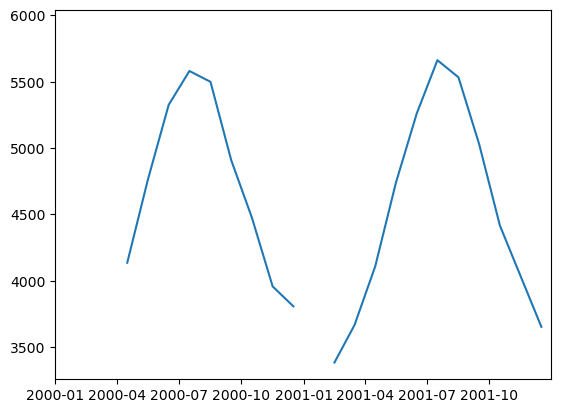

In [12]:
plt.plot(df['time'].values, df['FLH'].values)
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2001-12-31"))